In [1]:
!pip install nltk scikit-learn wordcloud seaborn kagglehub

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

Load Dataset

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "snap/amazon-fine-food-reviews",
    "Reviews.csv"
)

df.head()

/tmp/ipykernel_1628/440239261.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Select Required Columns

In [ ]:
df = df[['Text', 'Score']]
df.rename(columns={'Text': 'review'}, inplace=True)

df.head()

Create Sentiment Labels

In [5]:
def label(score):
    if score > 3:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['Score'].apply(label)

df['sentiment'].value_counts()

,count
sentiment,
Positive,443777
Negative,82037
Neutral,42640


In [10]:
df = df.sample(20000, random_state=42)
df.reset_index(drop=True, inplace=True)

Text Preprocessing Pipeline

In [13]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()   # added safety
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,review,Score,cleaned_review
0,Having tried a couple of other brands of glute...,5,tried couple brands glutenfree sandwich cookie...
1,My cat loves these treats. If ever I can't fin...,5,cat loves treats ever cant find house pop top ...
2,A little less than I expected. It tends to ha...,3,little less expected tends muddy taste expecte...
3,"First there was Frosted Mini-Wheats, in origin...",2,first frosted miniwheats original size frosted...
4,and I want to congratulate the graphic artist ...,5,want congratulate graphic artist putting entir...


TF-IDF + N-Grams

In [14]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)  # unigram + bigram
)

X = tfidf.fit_transform(df['cleaned_review'])

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (20000, 5000)


Lexicon-Based Sentiment Scoring

In [15]:
sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    return sia.polarity_scores(text)['compound']

df['sentiment_score'] = df['cleaned_review'].apply(get_sentiment_score)

df[['cleaned_review','sentiment_score']].head()

,cleaned_review,sentiment_score
0,tried couple brands glutenfree sandwich cookie...,0.9661
1,cat loves treats ever cant find house pop top ...,0.7106
2,little less expected tends muddy taste expecte...,0.4588
3,first frosted miniwheats original size frosted...,0.9899
4,want congratulate graphic artist putting entir...,0.9735


Convert Score → Sentiment Class

In [16]:
def classify(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['predicted_sentiment'] = df['sentiment_score'].apply(classify)

Sentiment Distribution Visualization

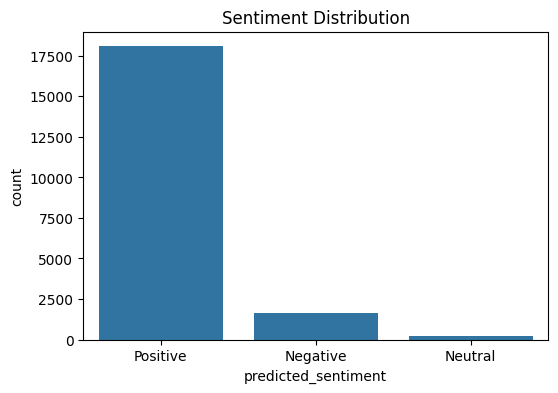

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='predicted_sentiment')
plt.title("Sentiment Distribution")
plt.show()

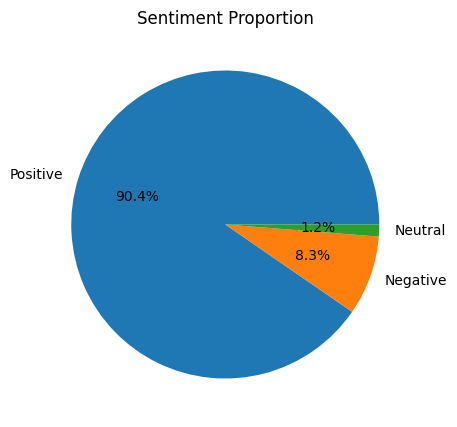

In [18]:
df['predicted_sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5)
)
plt.title("Sentiment Proportion")
plt.ylabel('')
plt.show()

WordCloud Visualization

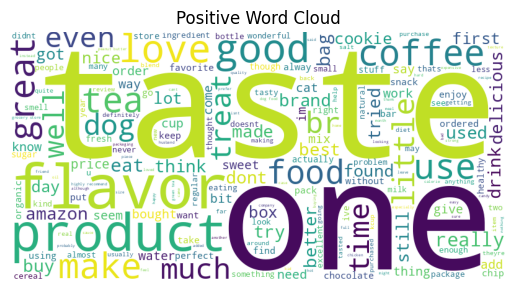

In [19]:
from wordcloud import WordCloud

positive_text = " ".join(df[df['predicted_sentiment']=='Positive']['cleaned_review'])

wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Positive Word Cloud")
plt.show()

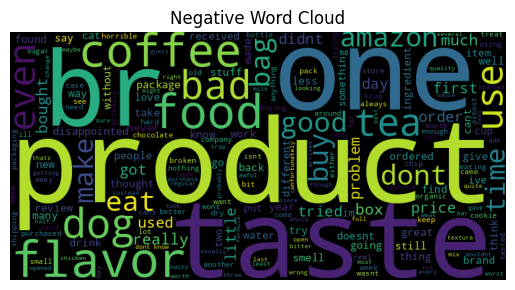

In [20]:
negative_text = " ".join(df[df['predicted_sentiment']=='Negative']['cleaned_review'])

wc = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Negative Word Cloud")
plt.show()